In [4]:
from typing import Annotated, List,TypedDict
import operator

from pydantic import BaseModel, Field
from IPython.display import Image, display, Markdown

from langchain_ollama import ChatOllama
from langgraph.types import Send
from langchain.messages import HumanMessage, SystemMessage
from langgraph.graph import START, END, StateGraph
from langchain_mcp_adapters.client import MultiServerMCPClient 
from langchain.agents import create_agent

In [16]:
client = MultiServerMCPClient(
    {
        "math": {
            "transport": "stdio",
            "command": "docker",
            "args": ["mcp", "gateway", "run"],
        }
    }
)

In [17]:
llm = ChatOllama(model="qwen3.5:4b")

tools = await client.get_tools()
llm = llm.bind_tools(tools)

In [25]:
client.connections

{'math': {'transport': 'stdio',
  'command': 'docker',
  'args': ['mcp', 'gateway', 'run']}}

In [4]:

# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )


# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

In [5]:
# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report


# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


In [6]:
# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report. Use a maximum of 4 "),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

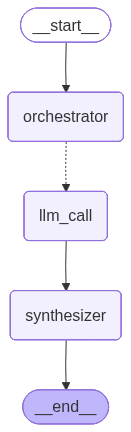

In [7]:
# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [ ]:
# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on the Cruzília city."}
                                   )

Markdown(state["final_report"])

TypeError: list indices must be integers or slices, not str

In [ ]:
fr = state[-1]['payload']['result']['final_report']

Markdown(fr)

In [ ]:
for section in state['sections']:
    print(section)

name='Introduction and Objectives' description='Define the Human Genome Project, its goal to sequence the human genome, and its significance in biology and medicine.'
name='Implementation and Timeline' description="Outline the project's duration (1990-2003), the international collaboration involved, and key milestones reached."
name='Scientific Achievements' description='Summarize the complete DNA sequence release, identification of genes, and advancements in genomics technology.'
name='Impact and Legacy' description='Discuss the revolution in genetics, medical diagnostics, ethical considerations (e.g., privacy), and future research directions.'


In [ ]:
len_sum = 0
for section in state['completed_sections']:
    print(f"{section.split("\n\n")[0]}: {len(section)/4}")
    len_sum += len(section)/4

print(f"TOTAL: {len_sum}")

# Introduction and Objectives: 686.5
## Implementation and Timeline: 566.0
# Scientific Achievements: 1134.0
## Impact and Legacy: 946.5
TOTAL: 3333.0


In [15]:
from langchain_pymupdf4llm import PyMuPDF4LLMLoader
from langchain_community.document_loaders.parsers import TesseractBlobParser
from langchain_text_splitters import RecursiveCharacterTextSplitter

file_path = "papers/CS/DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement LearningV1.pdf"

loader = PyMuPDF4LLMLoader(
    file_path,
    mode="single")

In [16]:
doc = loader.load()

In [19]:
splitter = RecursiveCharacterTextSplitter(chunk_size=4*8000, chunk_overlap=0)

In [20]:
len(splitter.split_text(doc[0].page_content))

3